In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,ConfusionMatrixDisplay


In [50]:
df = pd.read_csv("data.csv")
df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [51]:
df.dtypes

id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [52]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')

In [53]:
df.isna().mean()
## la colonne "Unnamed" ne contient aucune valeur, je vais la supprimer

id                         0.0
diagnosis                  0.0
radius_mean                0.0
texture_mean               0.0
perimeter_mean             0.0
area_mean                  0.0
smoothness_mean            0.0
compactness_mean           0.0
concavity_mean             0.0
concave points_mean        0.0
symmetry_mean              0.0
fractal_dimension_mean     0.0
radius_se                  0.0
texture_se                 0.0
perimeter_se               0.0
area_se                    0.0
smoothness_se              0.0
compactness_se             0.0
concavity_se               0.0
concave points_se          0.0
symmetry_se                0.0
fractal_dimension_se       0.0
radius_worst               0.0
texture_worst              0.0
perimeter_worst            0.0
area_worst                 0.0
smoothness_worst           0.0
compactness_worst          0.0
concavity_worst            0.0
concave points_worst       0.0
symmetry_worst             0.0
fractal_dimension_worst    0.0
Unnamed:

In [54]:
df = df.drop(columns=['id','Unnamed: 32'])

In [55]:
df["diagnosis"].unique()

<StringArray>
['M', 'B']
Length: 2, dtype: str

In [56]:
## Je vais encoder les valeurs "M" et "B". M par 1 et B par 0
df["diagnosis"] = df["diagnosis"].replace({"M":1,"B":0}).astype(int)

In [57]:
## Je sépare mes valeurs en données explicatives et en résultats
y = df["diagnosis"]
df = df.drop('diagnosis',axis=1)
X = df

In [58]:
## Je sépare mes données en données d'entrainement et données de test
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [59]:
# J'ai de grandes valeurs numériques pour mes caractéristiques. 
# Je vais les normaliser pour éviter un stack overflow au niveau du calcul de l'exponentielle
## Avec des valeurs normalisées, le neurone convergera plus rapidement
X = (X_train - X_train.mean())/X_train.std()
X.head(5)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
68,-1.439169,-0.434841,-1.360587,-1.137865,0.779715,0.718131,2.820030,-0.119019,1.091461,2.455470,...,-1.231506,-0.475786,-1.246548,-0.972897,0.722100,1.185427,4.667690,0.930988,2.094936,1.884376
181,1.971926,1.731120,2.089372,1.849937,1.318392,3.422508,2.010899,2.662102,2.124665,1.556682,...,2.170924,1.309838,2.079328,2.135055,0.761090,3.262010,1.926500,2.695979,1.889081,2.495092
63,-1.398443,-1.248248,-1.343730,-1.108565,-1.331180,-0.307017,-0.365156,-0.695736,1.928211,0.953329,...,-1.293859,-1.039667,-1.243851,-0.998616,-1.437111,-0.547961,-0.644202,-0.969172,0.596945,0.057831
248,-0.980717,1.414665,-0.981507,-0.865991,0.059325,-0.596132,-0.819301,-0.844186,0.312920,0.073960,...,-0.828286,1.591778,-0.872612,-0.742130,0.795748,-0.728590,-0.774098,-0.808593,0.798049,-0.134349
60,-1.116471,-1.009149,-1.123765,-0.964880,1.268115,-0.438519,-0.982260,-0.929577,3.390704,0.949168,...,-1.083936,-1.333149,-1.115910,-0.895563,-0.174683,-0.993985,-1.207817,-1.353092,1.032407,-0.205506


In [60]:
## Je vais générer des nombres aléatoires qui represente les paramètres du model et le biais
def init(X):
    np.random.seed(42)
    w = np.random.randn(X.shape[1])## les parametres represente les catégories explicatives
    b = np.random.randn()
    return w,b

In [61]:
def model(X,w,b):
    Z = X@w+b ## Je calcule un score en fonction des variables
    A = 1/(1+np.exp(-Z)) # Je le convertis en probabilité
    return A

In [62]:
def cout(A,X,y):## Je calcule la fonction cout. J'utilise la log_loss function
    loss = (-1/X.shape[0])*(np.dot(y,np.log(A))+np.dot((1-y),np.log(1-A)))
    return loss
    

In [63]:
## J'utilise la descente de gradient pour minimiser la log_loss function
def gradient(A,X,y):
    dw = (1/X.shape[0])*X.T@(A-y)
    db = (1/X.shape[0])*np.sum(A-y)
    return dw,db

In [64]:
def MAJ(w,b,dw,db,learning_rate):
    w = w - learning_rate*dw
    b = b - learning_rate*db
    return w,b

In [65]:
## l'entrainement
def fit(X,y,learning_rate = 0.1,iter = 100):
    w,b = init(X)
    perte = []
    for i in range(iter):
        A = model (X,w,b)
        loss = cout(A,X,y)
        perte.append(loss)
        dw,db = gradient(A,X,y)
        w,b = MAJ(w,b,dw,db,learning_rate)

    ## J'affiche la convergence du neurone
    plt.xlabel("itérations")
    plt.ylabel("Perte/Erreur")
    plt.plot(range(iter),perte)
    plt.show()
    return w,b
        

In [66]:
def predict(X,w,b):## je fixe mon seuil de décision a 50%
    return model(X,w,b)>=0.5

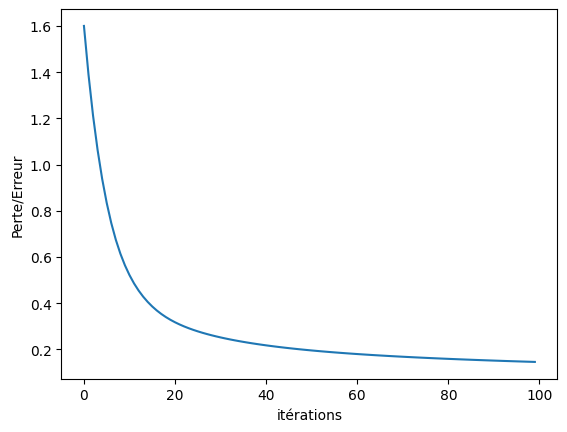

In [67]:
## On observe que le neurone converge
w,b = fit(X,y_train)


In [68]:
## Je normalise aussi les données de test
X_test = (X_test-X_test.mean())/X_test.std()

In [69]:
y_pred = predict(X_test,w,b)
y_pred

204    False
70      True
131     True
431    False
540    False
       ...  
486    False
75      True
249    False
238     True
265     True
Length: 114, dtype: bool

In [70]:
ac = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test, y_pred)

In [71]:
print(f"L'accuracy du neurone est de {ac}\nLe F1-score est {f1}")

L'accuracy du neurone est de 0.9298245614035088
Le F1-score est 0.9090909090909091


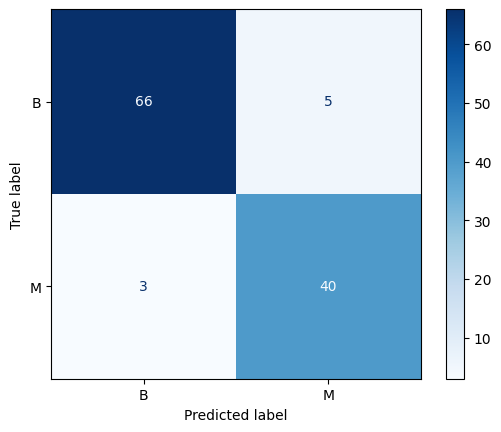

In [72]:
conf = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf, display_labels=["B", "M"])
disp.plot(cmap="Blues")
plt.show()